# Set Up

En este notebook se compara contra la epoca 15, y se toma como referencia los valores del famfold que yo mismo obtuve

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# plt.rc("text", usetex=True)
# plt.rc("font", family="serif")

In [12]:
experiments = [
    "hc_100",
    "hc_200",
    "hc_400",
    "rnadist_100",
    "rnadist_200",
    "rnadist_400",
    "samples_100",
    "samples_200",
    "samples_400",
]

# One Hot Encoding 15


In [13]:
def get_data(PATH):
    df = pd.read_csv(PATH, index_col=0)
    df.reset_index(inplace=True)
    df.rename(columns={"index": "fam"}, inplace=True)
    df_ref = df[["fam", "famfold"]]
    df_ref.sort_values(by="fam", ascending=False, inplace=True)
    df.drop(columns=["famfold"], inplace=True)
    return df, df_ref


PATH_OH = "SILVER/test_tables/OneHot_15_epochs_test.csv"
df, df_ref = get_data(PATH_OH)

display(df)
display(df_ref)

/tmp/ipykernel_2403865/2432570071.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ref.sort_values(by="fam", ascending=False, inplace=True)


,fam,hc_100,hc_200,hc_400,rnadist_100,rnadist_200,rnadist_400,samples_100,samples_200,samples_400
0,16s,0.176533,0.171753,0.154954,0.174203,0.170744,0.165594,0.156720,0.163572,0.160037
1,23s,0.248963,0.238251,0.234266,0.238278,0.221297,0.209013,0.232445,0.222398,0.218396
2,5s,0.268053,0.279704,0.297100,0.228899,0.248058,0.278214,0.285278,0.260221,0.290877
3,RNaseP,0.227096,0.216515,0.208379,0.227091,0.222811,0.204182,0.225096,0.207151,0.195743
4,grp1,0.188171,0.190160,0.178886,0.193354,0.186702,0.174508,0.186899,0.174148,0.189761
5,srp,0.156927,0.169713,0.161831,0.174751,0.171980,0.175378,0.157963,0.166569,0.168871
6,tRNA,0.369919,0.427000,0.438360,0.326411,0.435446,0.433944,0.366606,0.428908,0.426321
7,telomerase,0.136152,0.140468,0.145162,0.146255,0.145714,0.121199,0.161353,0.127018,0.117748
8,tmRNA,0.194175,0.203543,0.198519,0.196188,0.200216,0.184736,0.202698,0.200101,0.183869


,fam,famfold
8,tmRNA,0.167492
7,telomerase,0.114144
6,tRNA,0.465288
5,srp,0.165332
4,grp1,0.166082
3,RNaseP,0.183204
2,5s,0.281220
1,23s,0.209476
0,16s,0.152518


In [14]:
{
    "tmRNA": 0.1674917037517465,
    "telomerase": 0.114144392347629,
    "tRNA": 0.4652880783918064,
    "srp": 0.1653320431133,
    "grp1": 0.166081503499135,
    "RNaseP": 0.1832035462839154,
    "5s": 0.2812198125337743,
    "23s": 0.209475822929747,
    "16s": 0.1525179511457889,
}

{'tmRNA': 0.1674917037517465,
 'telomerase': 0.114144392347629,
 'tRNA': 0.4652880783918064,
 'srp': 0.1653320431133,
 'grp1': 0.166081503499135,
 'RNaseP': 0.1832035462839154,
 '5s': 0.2812198125337743,
 '23s': 0.209475822929747,
 '16s': 0.1525179511457889}

In [15]:
df_ref.set_index("fam")["famfold"].to_dict()

{'tmRNA': 0.1674917037517465,
 'telomerase': 0.114144392347629,
 'tRNA': 0.4652880783918064,
 'srp': 0.1653320431133,
 'grp1': 0.166081503499135,
 'RNaseP': 0.1832035462839154,
 '5s': 0.2812198125337743,
 '23s': 0.209475822929747,
 '16s': 0.1525179511457889}

In [16]:
def normalizar_y_melt(df, rna_llm, experiments):
    rna_llm_series = pd.Series(rna_llm.set_index("fam")["famfold"].to_dict())
    df_norm = df.copy()
    cols_to_normalize = [col for col in df.columns if col != "fam"]

    # Normalizar cada columna (vectorizado)
    df_norm[cols_to_normalize] = df_norm[cols_to_normalize].div(
        df_norm["fam"].map(rna_llm_series), axis=0
    )

    # Transformar a formato long
    dfn = df_norm.melt(
        id_vars="fam",
        value_vars=experiments,
        var_name="modelo",
        value_name="f1",
    )

    return dfn


def add_metodo_umbral(df: pd.DataFrame) -> pd.DataFrame:
    """Desglosa 'modelo' → ['metodo', 'umbral'] (string)."""
    out = df.copy()
    out[["metodo", "umbral"]] = out["modelo"].str.extract(r"([A-Za-z]+)_(\d+)")
    out["umbral"] = out["umbral"].astype(str)
    return out


# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)
dfn = normalizar_y_melt(df, df_ref, experiments)

In [17]:
s = dfn.groupby("modelo")["f1"].mean().sort_values().reset_index()
s = s.rename(columns={"f1": "rel_f1"})
s.to_csv("SILVER/rel_f1_tables/OneHot_15_epochs_relf1.csv")
s

,modelo,rel_f1
0,rnadist_400,1.044027
1,samples_400,1.044917
2,samples_200,1.052839
3,rnadist_100,1.078726
4,hc_100,1.085338
5,hc_400,1.087027
6,rnadist_200,1.094044
7,samples_100,1.096974
8,hc_200,1.108329


In [18]:
PALETTE = {"100": "#1B9E77", "200": "#D95F02", "400": "#7570B3"}
MARKERS = {"hc": "*", "samples": "o", "rnadist": "^"}


dfl = add_metodo_umbral(dfl)  # absolutos
dfn = add_metodo_umbral(dfn)  # normalizados


# plot utils
def strip(ax, df, fam_map, seed=0):
    """Scatter categórico con jitter: color=umbral, marker=método."""
    # jitter
    rng = np.random.default_rng(seed)
    x = df["fam"].map(fam_map) + rng.uniform(-0.25, 0.25, len(df["fam"]))
    # plot
    for metodo, g in df.groupby("metodo"):
        ax.scatter(
            x[g.index],
            g["f1"],
            marker=MARKERS.get(metodo, "o"),
            c=[PALETTE[u] for u in g["umbral"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=metodo,
        )


def combined_legend(fig, axes):
    """Leyenda única (métodos + umbrales) sin duplicados."""
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
        if ax.get_legend():
            ax.get_legend().remove()

    color_handles = [
        Line2D([0], [0], marker="D", ls="", color=PALETTE[u], label=u) for u in PALETTE
    ]
    handles += color_handles
    labels += [h.get_label() for h in color_handles]

    uniq = dict(zip(labels, handles))
    fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=5, frameon=False)

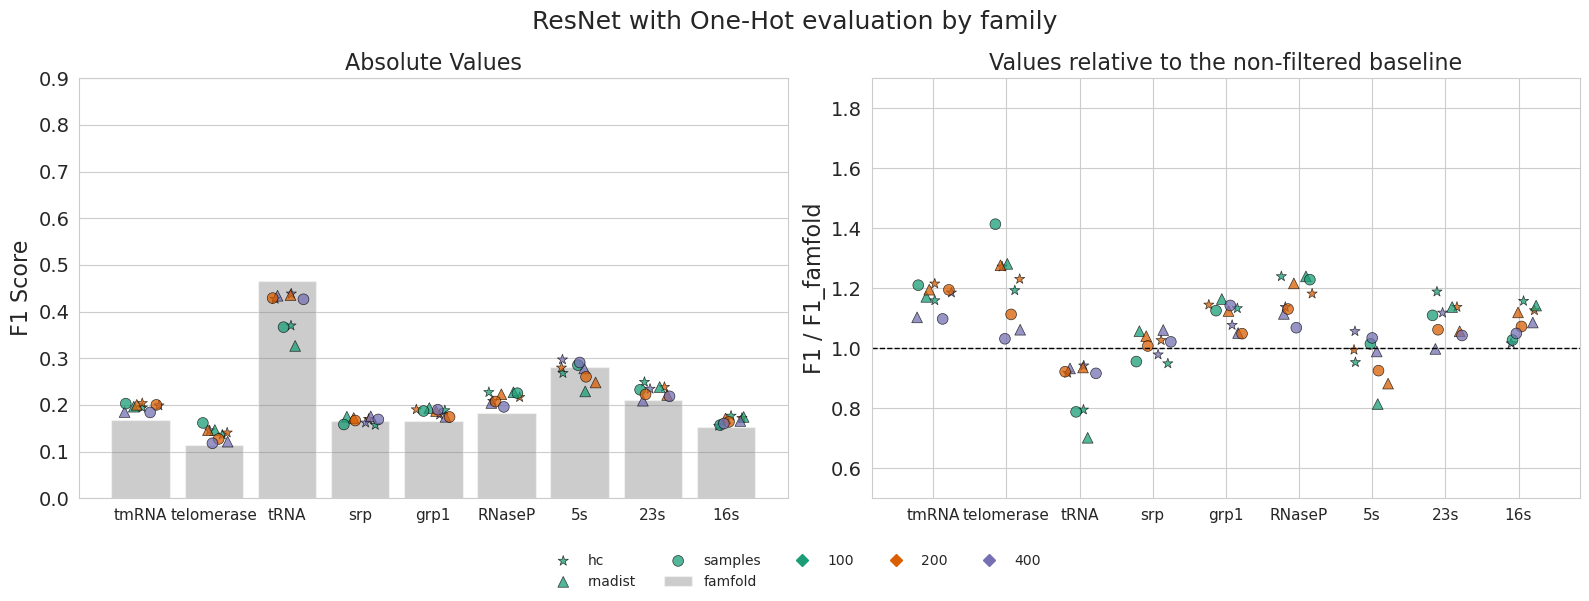

In [ ]:
fam_order = sorted(dfl["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

# ────────────── PLOT ──────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Panel A: valores absolutos
sns.barplot(
    data=df_ref,
    x="fam",
    y="famfold",
    color="gray",
    alpha=0.4,
    errorbar=None,
    ax=axes[0],
    label="famfold",
)
strip(axes[0], dfl, fam_map)
axes[0].set_ylim(0, 0.9)
axes[0].set_title("Absolute Values", fontsize=16)
axes[0].set_ylabel("F1 Score", fontsize=16) 
axes[0].yaxis.set_tick_params(labelsize=14)


# Panel B: valores relativos
strip(axes[1], dfn, fam_map)
axes[1].axhline(1, ls="--", lw=1, color="k")
axes[1].set_ylim(0.5, 1.9)
axes[1].set_title("Values relative to the non-filtered baseline", fontsize=16)
axes[1].set_ylabel("F1 / F1_famfold", fontsize=16)
axes[1].yaxis.set_tick_params(labelsize=14)

# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order, fontsize=11)
# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order)

fig.suptitle("ResNet with One-Hot evaluation by family", fontsize=18)
combined_legend(fig, axes)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [20]:
print(dfl)

           fam       modelo        f1   metodo umbral
0          16s       hc_100  0.176533       hc    100
1          23s       hc_100  0.248963       hc    100
2           5s       hc_100  0.268053       hc    100
3       RNaseP       hc_100  0.227096       hc    100
4         grp1       hc_100  0.188171       hc    100
..         ...          ...       ...      ...    ...
76        grp1  samples_400  0.189761  samples    400
77         srp  samples_400  0.168871  samples    400
78        tRNA  samples_400  0.426321  samples    400
79  telomerase  samples_400  0.117748  samples    400
80       tmRNA  samples_400  0.183869  samples    400

[81 rows x 5 columns]


# RiNALMo

In [21]:
PATH_RiNALMo = "SILVER/test_tables/RiNALMo_15_epochs_test.csv"
df, df_ref = get_data(PATH_RiNALMo)

display(df)
display(df_ref)

/tmp/ipykernel_2403865/2432570071.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ref.sort_values(by="fam", ascending=False, inplace=True)


,fam,hc_100,hc_200,hc_400,rnadist_100,rnadist_200,rnadist_400,samples_100,samples_200,samples_400
0,16s,0.441631,0.458123,0.520438,0.413338,0.462140,0.456747,0.421239,0.459383,0.552313
1,23s,0.517211,0.534760,0.611863,0.496194,0.578091,0.579155,0.519056,0.563238,0.597884
2,5s,0.746607,0.763970,0.768595,0.730811,0.744533,0.763696,0.775930,0.745209,0.749873
3,RNaseP,0.559993,0.645640,0.624507,0.612839,0.633260,0.619183,0.589208,0.603671,0.587982
4,grp1,0.511049,0.527383,0.546749,0.540281,0.558154,0.544809,0.483329,0.519261,0.540803
5,srp,0.530609,0.573562,0.583741,0.546316,0.559678,0.572559,0.561299,0.565040,0.554591
6,tRNA,0.844595,0.867271,0.867267,0.825141,0.851912,0.863043,0.841429,0.874955,0.853181
7,telomerase,0.136816,0.101971,0.089344,0.125292,0.121063,0.102304,0.083072,0.094594,0.097243
8,tmRNA,0.549949,0.616359,0.630807,0.570237,0.606862,0.656603,0.594807,0.606080,0.649080


,fam,famfold
8,tmRNA,0.620926
7,telomerase,0.090693
6,tRNA,0.835476
5,srp,0.586522
4,grp1,0.474777
3,RNaseP,0.653999
2,5s,0.739421
1,23s,0.573340
0,16s,0.509853


In [22]:
# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)

dfn = normalizar_y_melt(df, df_ref, experiments)
s = dfn.groupby("modelo")["f1"].mean().sort_values().reset_index()
s = s.rename(columns={"f1": "rel_f1"})

s.to_csv("SILVER/rel_f1_tables/RiNALMo_15_epochs_relf1.csv")
s

,modelo,rel_f1
0,samples_100,0.948652
1,samples_200,0.993077
2,rnadist_100,0.995386
3,hc_100,1.002279
4,hc_200,1.010604
5,rnadist_400,1.025306
6,samples_400,1.029185
7,hc_400,1.029806
8,rnadist_200,1.039072


In [23]:
dfl = add_metodo_umbral(dfl)  # absolutos
dfn = add_metodo_umbral(dfn)  # normalizados

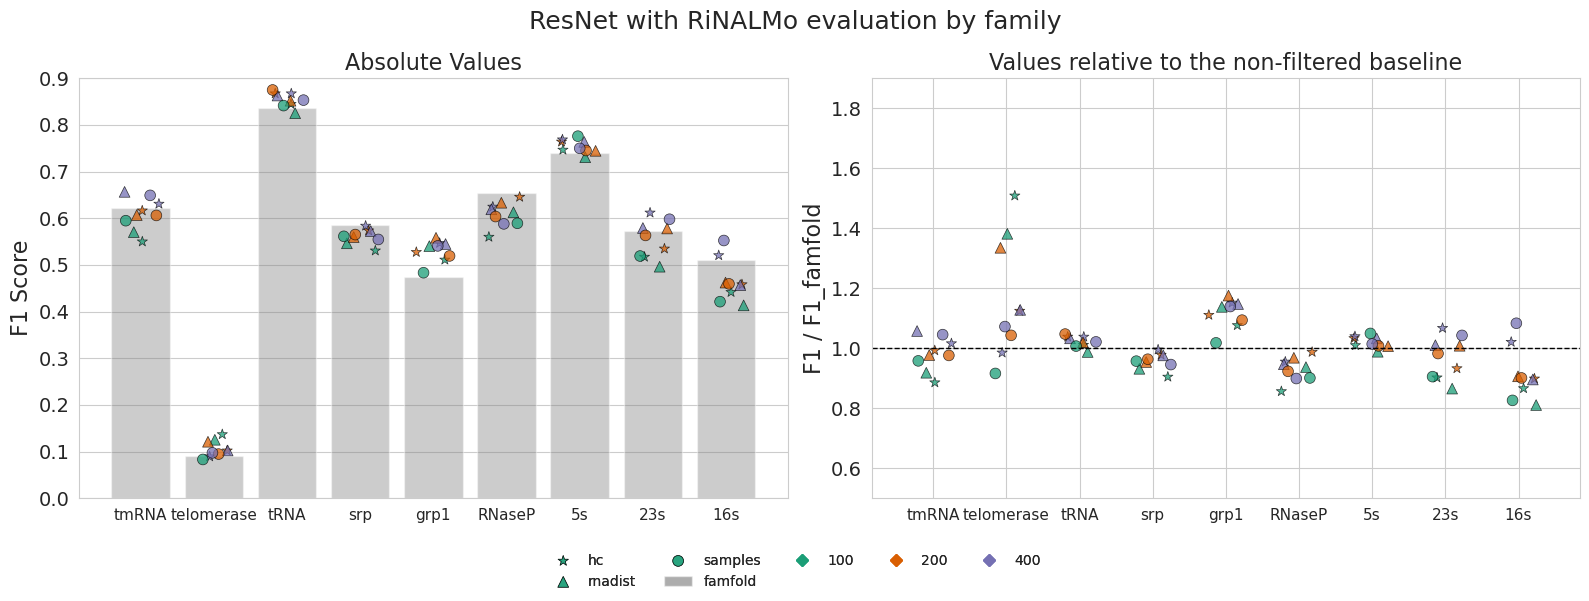

In [ ]:
fam_order = sorted(dfl["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

# ────────────── PLOT ──────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Panel A: valores absolutos
sns.barplot(
    data=df_ref,
    x="fam",
    y="famfold",
    color="gray",
    alpha=0.4,
    errorbar=None,
    ax=axes[0],
    label="famfold",
)

strip(axes[0], dfl, fam_map)
axes[0].set_ylim(0, 0.9)
axes[0].set_title("Absolute Values", fontsize=16)
axes[0].set_ylabel("F1 Score", fontsize=16) 
axes[0].yaxis.set_tick_params(labelsize=14)


# Panel B: valores relativos
strip(axes[1], dfn, fam_map)
axes[1].axhline(1, ls="--", lw=1, color="k")
axes[1].set_ylim(0.5, 1.9)
axes[1].set_title("Values relative to the non-filtered baseline", fontsize=16)
axes[1].set_ylabel("F1 / F1_famfold", fontsize=16)
axes[1].yaxis.set_tick_params(labelsize=14)

# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order, fontsize=11)
# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order)

fig.suptitle("ResNet with RiNALMo evaluation by family", fontsize=18)
combined_legend(fig, axes)

combined_legend(fig, axes)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()